In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv",low_memory=False)

In [3]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [5]:
df.shape

(364558, 53)

In [6]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

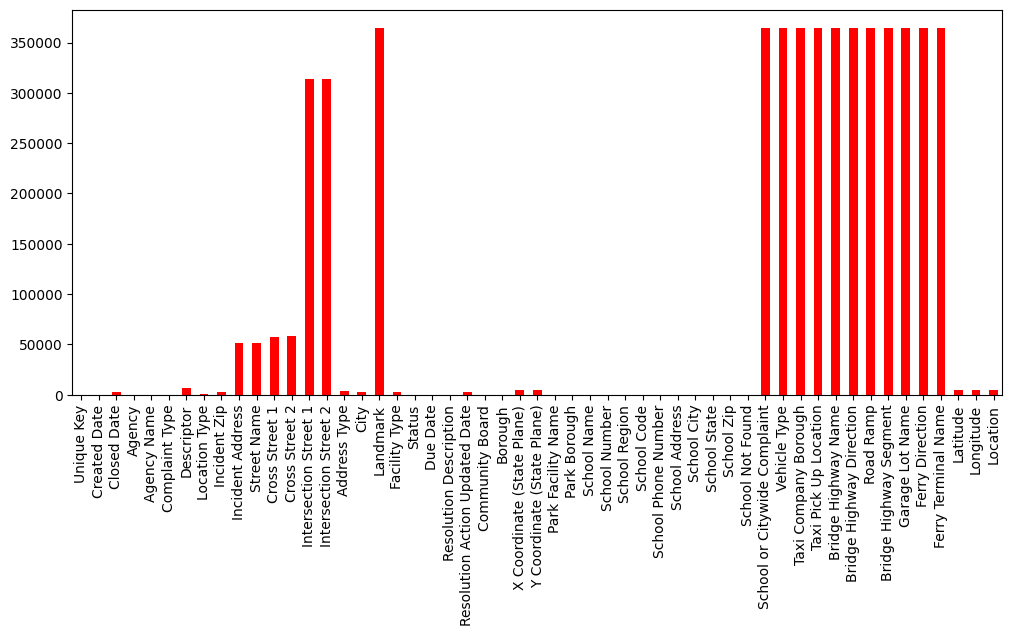

In [7]:
plt.figure(figsize=(12,5))
df.isnull().sum().plot(kind='bar',color='r')
plt.show()

In [8]:
(df.isnull().sum()/len(df))*100

Unique Key                          0.000000
Created Date                        0.000000
Closed Date                         0.653120
Agency                              0.000000
Agency Name                         0.000000
Complaint Type                      0.000000
Descriptor                          1.783255
Location Type                       0.036483
Incident Zip                        0.822366
Incident Address                   14.181283
Street Name                        14.181283
Cross Street 1                     15.686941
Cross Street 2                     15.856187
Intersection Street 1              85.977540
Intersection Street 2              86.144317
Address Type                        0.892039
City                                0.822091
Landmark                           99.897136
Facility Type                       0.655314
Status                              0.000000
Due Date                            0.000823
Resolution Description              0.000000
Resolution

In [9]:
df=df.dropna(axis=1,how='all')

In [10]:
df.shape

(364558, 48)

In [11]:
cols=df.columns[df.isnull().mean() >= 0.99]

In [12]:
cols

Index(['Landmark', 'Bridge Highway Name', 'Bridge Highway Direction',
       'Road Ramp', 'Bridge Highway Segment', 'Ferry Direction',
       'Ferry Terminal Name'],
      dtype='object')

In [13]:
df=df.drop(cols,axis=True)

In [14]:
df.isnull().mean()*100

Unique Key                         0.000000
Created Date                       0.000000
Closed Date                        0.653120
Agency                             0.000000
Agency Name                        0.000000
Complaint Type                     0.000000
Descriptor                         1.783255
Location Type                      0.036483
Incident Zip                       0.822366
Incident Address                  14.181283
Street Name                       14.181283
Cross Street 1                    15.686941
Cross Street 2                    15.856187
Intersection Street 1             85.977540
Intersection Street 2             86.144317
Address Type                       0.892039
City                               0.822091
Facility Type                      0.655314
Status                             0.000000
Due Date                           0.000823
Resolution Description             0.000000
Resolution Action Updated Date     0.658880
Community Board                 

In [15]:
df=df.drop(columns=['Intersection Street 1','Intersection Street 2'],axis=True)

In [16]:
df.isnull().mean()*100

Unique Key                         0.000000
Created Date                       0.000000
Closed Date                        0.653120
Agency                             0.000000
Agency Name                        0.000000
Complaint Type                     0.000000
Descriptor                         1.783255
Location Type                      0.036483
Incident Zip                       0.822366
Incident Address                  14.181283
Street Name                       14.181283
Cross Street 1                    15.686941
Cross Street 2                    15.856187
Address Type                       0.892039
City                               0.822091
Facility Type                      0.655314
Status                             0.000000
Due Date                           0.000823
Resolution Description             0.000000
Resolution Action Updated Date     0.658880
Community Board                    0.000000
Borough                            0.000000
X Coordinate (State Plane)      

In [17]:
df['Incident Address'].fillna('Unknown',inplace=True)
df['Street Name'].fillna('Unknown',inplace=True)
df['Cross Street 1'].fillna('Unknown',inplace=True)
df['Cross Street 2'].fillna('Unknown',inplace=True)
df['Descriptor'].fillna('Unknown',inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_2900\880283166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Incident Address'].fillna('Unknown',inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_2900\880283166.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [18]:
df=df.dropna(subset=['Closed Date'])
df=df.dropna(subset=['Location Type'])
df=df.dropna(subset=['Incident Zip'])
df=df.dropna(subset=['Address Type'])
df=df.dropna(subset=['City'])
df=df.dropna(subset=['Facility Type'])
df=df.dropna(subset=['Resolution Action Updated Date'])
df=df.dropna(subset=['X Coordinate (State Plane)'])
df=df.dropna(subset=['Y Coordinate (State Plane)'])

In [19]:
df.isnull().mean()*100

Unique Key                        0.0
Created Date                      0.0
Closed Date                       0.0
Agency                            0.0
Agency Name                       0.0
Complaint Type                    0.0
Descriptor                        0.0
Location Type                     0.0
Incident Zip                      0.0
Incident Address                  0.0
Street Name                       0.0
Cross Street 1                    0.0
Cross Street 2                    0.0
Address Type                      0.0
City                              0.0
Facility Type                     0.0
Status                            0.0
Due Date                          0.0
Resolution Description            0.0
Resolution Action Updated Date    0.0
Community Board                   0.0
Borough                           0.0
X Coordinate (State Plane)        0.0
Y Coordinate (State Plane)        0.0
Park Facility Name                0.0
Park Borough                      0.0
School Name 

In [20]:
df.shape

(360004, 39)

In [21]:
df = df[df['Closed Date'].notnull()]

In [22]:
df['Closed Date']

0         01/01/2016 12:55:15 AM
1         01/01/2016 01:26:57 AM
2         01/01/2016 04:51:03 AM
3         01/01/2016 07:43:13 AM
4         01/01/2016 03:24:42 AM
                   ...          
364553    01/01/2015 10:22:31 AM
364554    01/01/2015 02:25:02 AM
364555    01/01/2015 12:20:33 AM
364556    01/01/2015 02:42:22 AM
364557    01/01/2015 02:47:50 AM
Name: Closed Date, Length: 360004, dtype: object

In [23]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

C:\Users\admin\AppData\Local\Temp\ipykernel_2900\1322958625.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'])
C:\Users\admin\AppData\Local\Temp\ipykernel_2900\1322958625.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'])


In [24]:
df['Created Date']

0        2015-12-31 23:59:45
1        2015-12-31 23:59:44
2        2015-12-31 23:59:29
3        2015-12-31 23:57:46
4        2015-12-31 23:56:58
                 ...        
364553   2015-01-01 00:04:44
364554   2015-01-01 00:04:28
364555   2015-01-01 00:01:30
364556   2015-01-01 00:01:29
364557   2015-01-01 00:00:50
Name: Created Date, Length: 360004, dtype: datetime64[ns]

In [25]:
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

In [26]:
df['Request_Closing_Time'].head(25)

0    0 days 00:55:30
1    0 days 01:27:13
2    0 days 04:51:34
3    0 days 07:45:27
4    0 days 03:27:44
5    0 days 01:53:41
6    0 days 01:58:22
7    0 days 01:48:49
8    0 days 08:33:34
9    0 days 01:23:42
10   0 days 07:48:40
11   0 days 11:07:11
12   0 days 02:29:56
13   0 days 08:30:49
14   0 days 10:29:45
15   0 days 15:33:27
16   0 days 04:52:39
17   0 days 00:51:18
18   0 days 02:56:29
19   0 days 00:47:36
20   0 days 04:31:52
21   0 days 09:32:42
22   0 days 01:16:38
23   0 days 00:52:35
24   2 days 16:51:12
Name: Request_Closing_Time, dtype: timedelta64[ns]

In [27]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [28]:
df['Request_Closing_Time'].head(25)

0       3330.0
1       5233.0
2      17494.0
3      27927.0
4      12464.0
5       6821.0
6       7102.0
7       6529.0
8      30814.0
9       5022.0
10     28120.0
11     40031.0
12      8996.0
13     30649.0
14     37785.0
15     56007.0
16     17559.0
17      3078.0
18     10589.0
19      2856.0
20     16312.0
21     34362.0
22      4598.0
23      3155.0
24    233472.0
Name: Request_Closing_Time, dtype: float64

In [29]:
df = df[df['Request_Closing_Time'] >= 0]
df['Request_Closing_Time']

0          3330.0
1          5233.0
2         17494.0
3         27927.0
4         12464.0
           ...   
364553    37067.0
364554     8434.0
364555     1143.0
364556     9653.0
364557    10020.0
Name: Request_Closing_Time, Length: 360004, dtype: float64

In [30]:
df['City'].value_counts()
df['Complaint Type'].value_counts()

Complaint Type
Blocked Driveway             100454
Illegal Parking               91056
Noise - Street/Sidewalk       50788
Noise - Commercial            43623
Derelict Vehicle              21405
Noise - Vehicle               19121
Animal Abuse                  10499
Traffic                        4908
Homeless Encampment            4794
Vending                        4162
Noise - Park                   3994
Drinking                       1399
Noise - House of Worship       1059
Posting Advertisement           678
Urinating in Public             640
Bike/Roller/Skate Chronic       463
Panhandling                     319
Disorderly Youth                314
Illegal Fireworks               167
Graffiti                        157
Squeegee                          4
Name: count, dtype: int64

In [31]:
df['City'] = df['City'].fillna("Unknown")

In [32]:
df['City'].head(50)

0                NEW YORK
1                 ASTORIA
2                   BRONX
3                   BRONX
4                ELMHURST
5                BROOKLYN
6                NEW YORK
7                   BRONX
8             KEW GARDENS
9                BROOKLYN
10        JACKSON HEIGHTS
11                  BRONX
12                  BRONX
13               BROOKLYN
14         MIDDLE VILLAGE
15              REGO PARK
16           SAINT ALBANS
17               BROOKLYN
18               BROOKLYN
19               NEW YORK
20                  BRONX
21         MIDDLE VILLAGE
22               BROOKLYN
23               NEW YORK
24                  BRONX
25                JAMAICA
26               NEW YORK
27    SOUTH RICHMOND HILL
28               NEW YORK
29               BROOKLYN
30               BROOKLYN
31               BROOKLYN
32                  BRONX
34              RIDGEWOOD
35           HOWARD BEACH
36               BROOKLYN
37           FOREST HILLS
38               BROOKLYN
39          

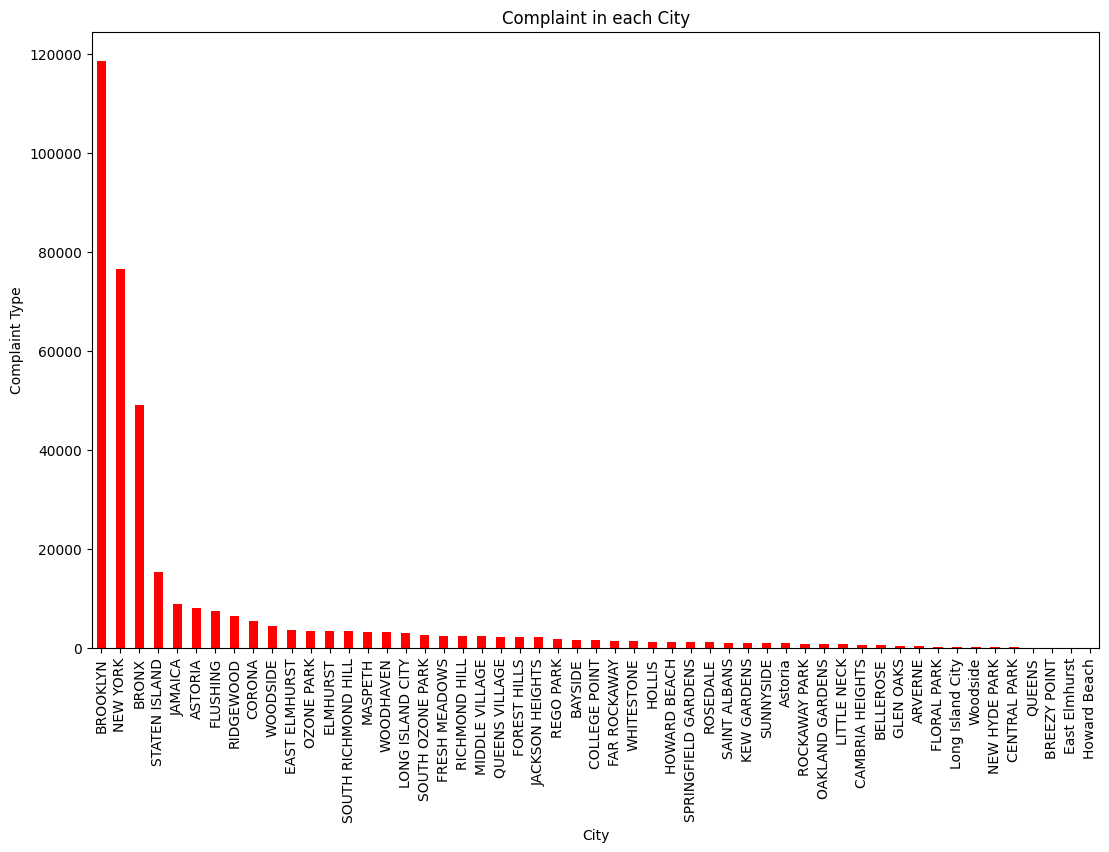

In [33]:
plt.figure(figsize=(13,8))
df['City'].value_counts().plot(kind='bar',color='red')
plt.xlabel('City')
plt.ylabel('Complaint Type')
plt.title('Complaint in each City')
plt.show()

In [34]:
BROOKLYN = df[df['City'] == 'BROOKLYN']

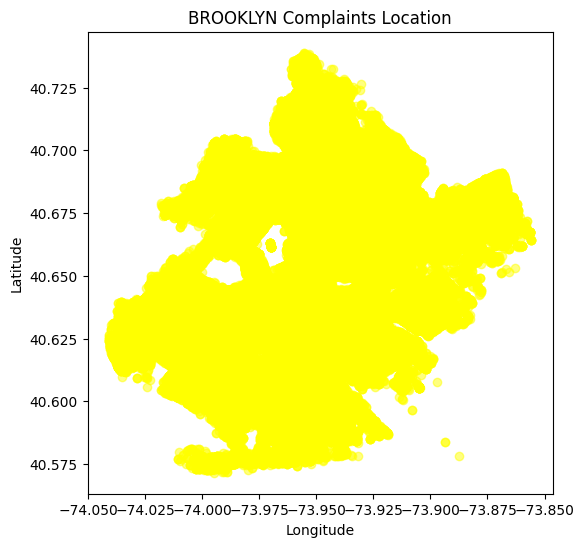

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(BROOKLYN['Longitude'], BROOKLYN['Latitude'], alpha=0.5,color='yellow')
plt.title("BROOKLYN Complaints Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<Figure size 1300x800 with 0 Axes>

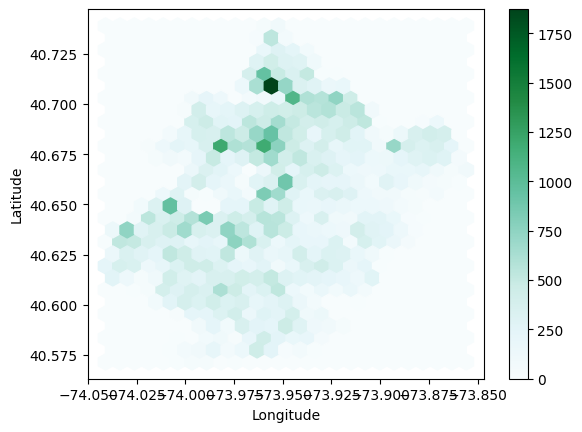

In [36]:
plt.figure(figsize=(13,8))
BROOKLYN.plot.hexbin(x='Longitude', y='Latitude', gridsize=25)
plt.show()

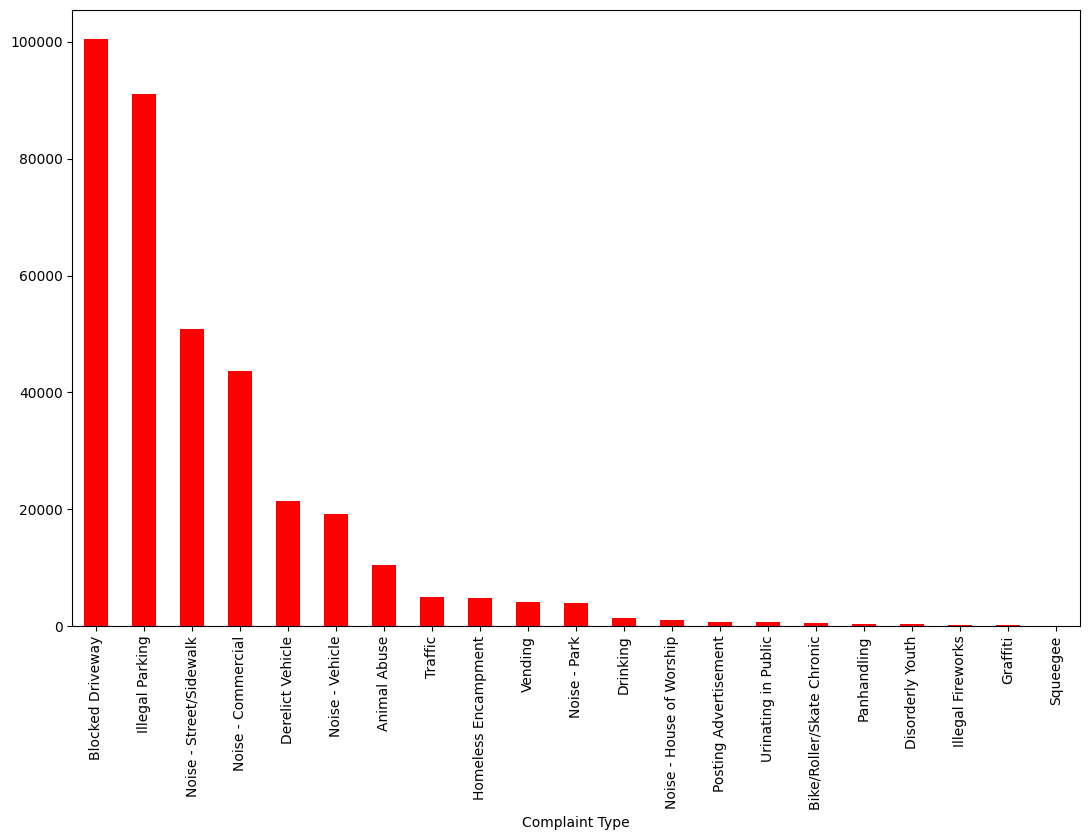

In [37]:
plt.figure(figsize=(13,8))
df['Complaint Type'].value_counts().plot(kind='bar',color='red')
plt.show()

In [38]:
pratham = df[df['City'] == 'NEW YORK']
pratham['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22076
Noise - Commercial           18666
Illegal Parking              14365
Noise - Vehicle               6178
Homeless Encampment           3003
Blocked Driveway              2686
Vending                       2619
Animal Abuse                  1926
Traffic                       1675
Noise - Park                  1200
Derelict Vehicle               685
Drinking                       320
Urinating in Public            264
Bike/Roller/Skate Chronic      249
Noise - House of Worship       217
Panhandling                    203
Disorderly Youth                80
Posting Advertisement           49
Illegal Fireworks               34
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

In [39]:
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100454
Illegal Parking             91056
Noise - Street/Sidewalk     50788
Noise - Commercial          43623
Derelict Vehicle            21405
Noise - Vehicle             19121
Animal Abuse                10499
Traffic                      4908
Homeless Encampment          4794
Vending                      4162
Name: count, dtype: int64

In [40]:
df.groupby(['City','Complaint Type']).size()

City      Complaint Type         
ARVERNE   Animal Abuse                46
          Blocked Driveway            50
          Derelict Vehicle            32
          Disorderly Youth             2
          Drinking                     1
                                    ... 
Woodside  Blocked Driveway            27
          Derelict Vehicle             8
          Illegal Parking            124
          Noise - Commercial           2
          Noise - Street/Sidewalk      5
Length: 776, dtype: int64

In [41]:
df_new = pd.crosstab(df['Complaint Type'], df['City'])

In [42]:
df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Animal Abuse,46,170,0,53,15,2,1965,3185,15,0,...,43,74,40,42,786,40,43,57,111,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,121,0,0,...,0,1,1,0,9,2,4,2,5,0
Blocked Driveway,50,3436,159,513,138,3,17048,36414,177,0,...,318,1202,1945,330,2844,278,279,1363,2036,27
Derelict Vehicle,32,426,14,231,120,3,2396,6239,148,0,...,248,425,356,266,2180,17,278,369,297,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,...,1,2,2,0,25,2,1,0,1,0


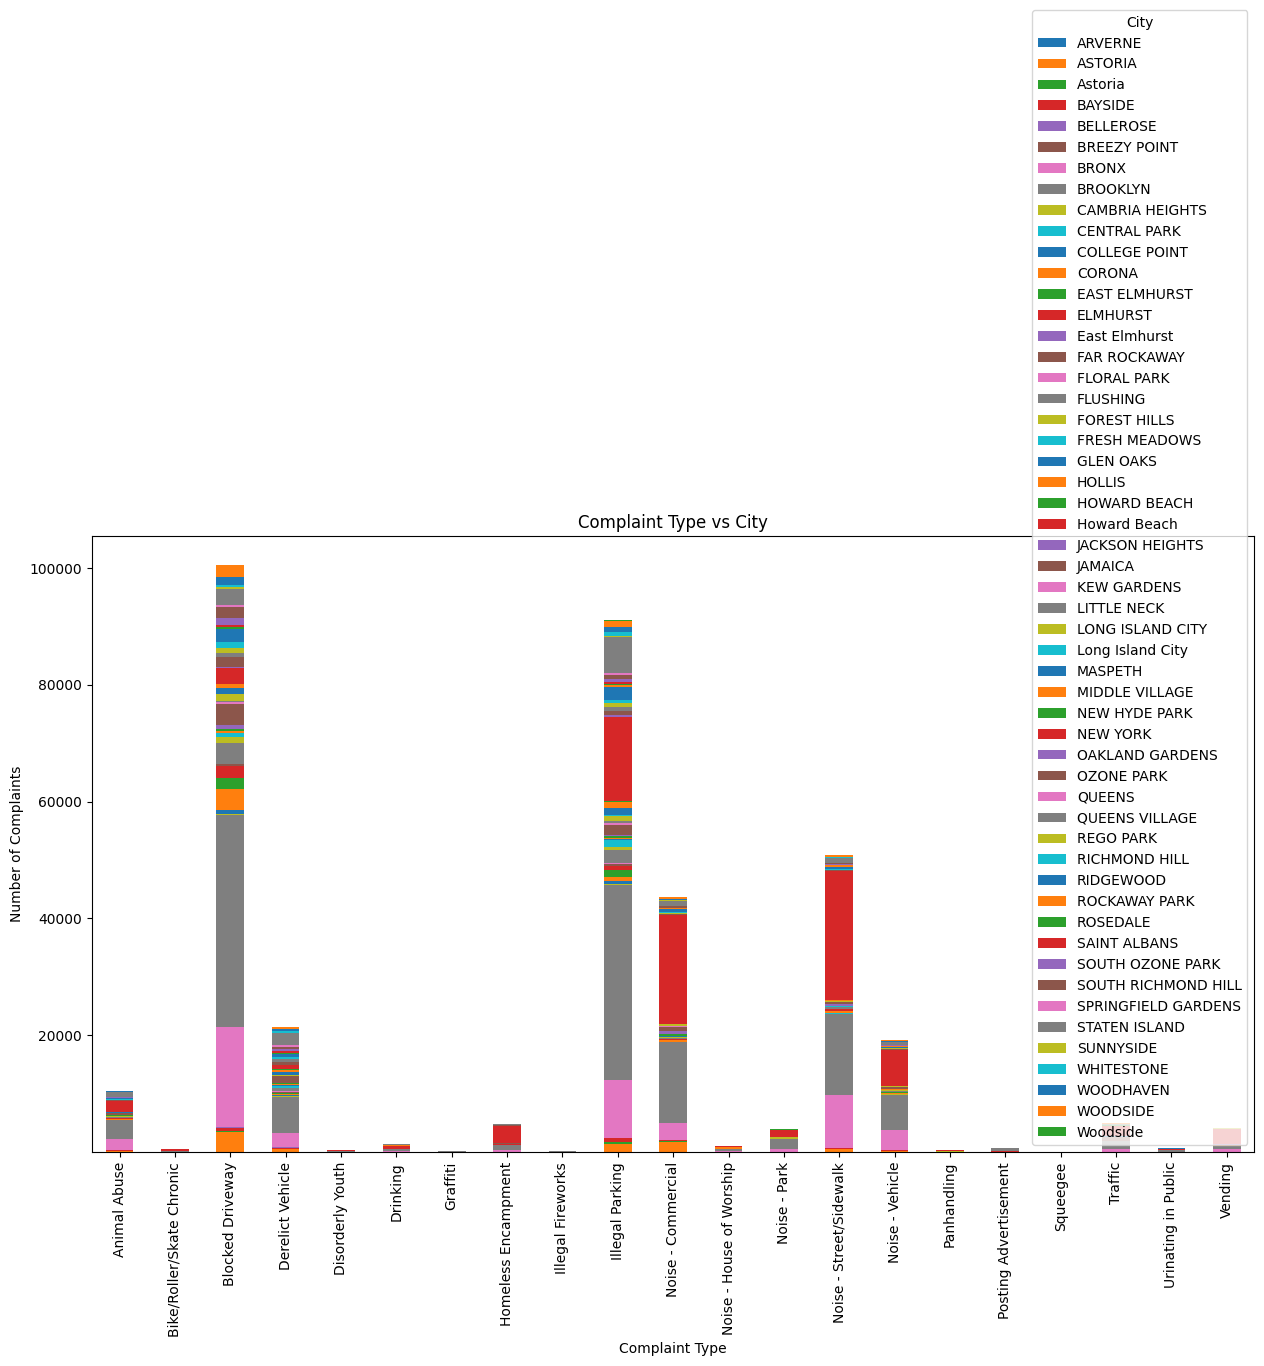

In [43]:
df_new.plot(kind='bar', stacked=True,figsize=(15,8))
plt.title("Complaint Type vs City")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.show()

In [44]:
df.groupby('Complaint Type')['Request_Closing_Time'].mean().reset_index()

,Complaint Type,Request_Closing_Time
0,Animal Abuse,18037.952948
1,Bike/Roller/Skate Chronic,12941.995680
2,Blocked Driveway,16217.993728
3,Derelict Vehicle,25289.966924
4,Disorderly Youth,12395.754777
5,Drinking,13805.907791
6,Graffiti,23276.343949
7,Homeless Encampment,15367.192115
8,Illegal Fireworks,10122.347305
9,Illegal Parking,15582.957312


In [45]:
overall_avg=df.groupby('Complaint Type')['Request_Closing_Time'].mean().sort_values()
overall_avg

Complaint Type
Posting Advertisement         7287.171091
Illegal Fireworks            10122.347305
Noise - Commercial           11042.455562
Noise - House of Worship     11410.395656
Noise - Park                 12196.250125
Noise - Street/Sidewalk      12216.512857
Disorderly Youth             12395.754777
Traffic                      12403.320090
Noise - Vehicle              12581.080540
Bike/Roller/Skate Chronic    12941.995680
Urinating in Public          12957.056250
Drinking                     13805.907791
Vending                      14355.265738
Squeegee                     14560.250000
Panhandling                  15241.636364
Homeless Encampment          15367.192115
Illegal Parking              15582.957312
Blocked Driveway             16217.993728
Animal Abuse                 18037.952948
Graffiti                     23276.343949
Derelict Vehicle             25289.966924
Name: Request_Closing_Time, dtype: float64

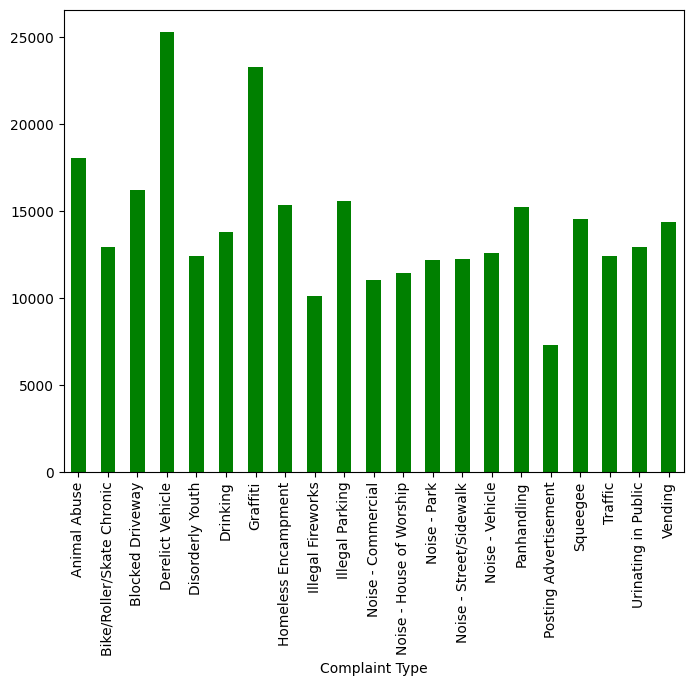

In [46]:
plt.figure(figsize=(8,6))
df.groupby('Complaint Type')['Request_Closing_Time'].mean().plot(kind='bar',color ='green')
plt.show()

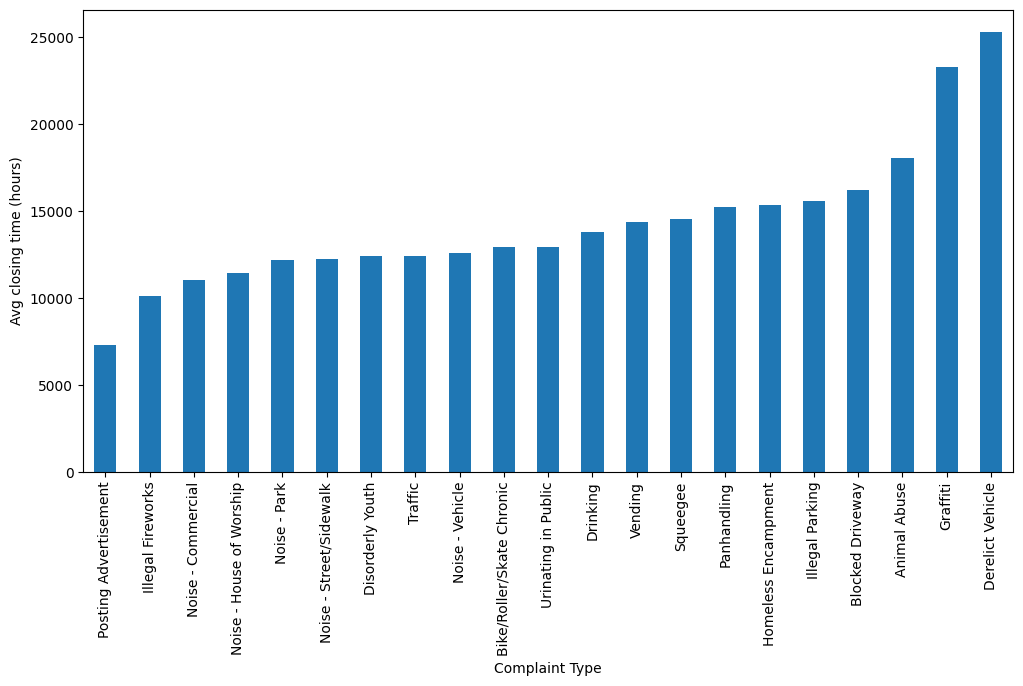

In [47]:
overall_avg.plot(kind='bar',figsize=(12,6))
plt.xlabel('Complaint Type')
plt.ylabel('Avg closing time (hours)')
plt.show()

In [48]:
from scipy.stats import kruskal
types = df['Complaint Type'].unique()
groups = [df[df['Complaint Type']==t]['Request_Closing_Time'] for t in types[:5]]
kruskal(*groups)

KruskalResult(statistic=np.float64(9986.827345702266), pvalue=np.float64(0.0))